In [1]:
import pandas as pd
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import ExcelWriter
from pandas import ExcelFile
from sklearn import preprocessing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:

dem_list=['DEM_SEX','DEM_AGE','DEM_RACE'] # Demographic information for deviding the data for different race, sex and possibly age groups  
feat_list=['CA_CIRC_W','CA_CIRC_H'] # These two features are the input of the function for drawing scatter plots 
filt_race=1 # 0--> No filtration by race, 1-->Filter by race (Filtration by Sex is defult)

address='/Users/Ali/Desktop/Data_Sima/Standard_Labels/AllStyku_v14.xlsx' # Importing dataset. "in_data" will be used in the Scatt_plot function
in_data=pd.read_excel(address,encoding = "ISO-8859-1")



In [3]:
# This function make a scatter plot and a regression line based on two chosen features
def Scat_Reg(Data):
    
    X=Data[feat_list[0]].values.reshape(-1, 1)
    Y=Data[feat_list[1]].values.reshape(-1, 1)
    linear_regressor = LinearRegression()  # create object for the class
    linear_regressor.fit(X, Y)  # perform linear regression
    Y_pred = linear_regressor.predict(X)  # make predictions
    fig, ax = plt.subplots()
    plt.scatter(X, Y, marker='.', color='k')
    plt.plot(X, Y_pred, color='red', ls='--')

    print("Regression line: Y = %0.2f X + %0.2f" % (linear_regressor.coef_[0],linear_regressor.intercept_))
    print("R-Squared value: %0.2f " %r2_score(Y, Y_pred))
  
    ax.set_xlabel(feat_list[0])
    ax.set_ylabel(feat_list[1])
    plt.show()
    
    return

In [10]:
# This fubction make differnt data subsets based on race and gender, then draw the scatter plot with regression line for each of them.
# This function take the dataset, two features and a filter for deviding based on race as inputs
def Scatt_plot(in_data,feat_list,filt_race=0):    
    
    dem_list=['DEM_SEX','DEM_AGE','DEM_RACE']   
    feat_reg=dem_list+feat_list

    sam_data=in_data[feat_reg] # Making the sample data set based on the "dem_list" and "feat_list"
    sam_data=sam_data.dropna() # Removing NAN rows from the sample data
    
    #Making datasets for different subgroups of sample dataset (based on sex and race)
    Data_M=sam_data.loc[sam_data['DEM_SEX']=='M']  #Only Male
    Data_F=sam_data.loc[sam_data['DEM_SEX']=='F']  #Only Female
    Data_M_A=Data_M.loc[Data_M['DEM_RACE']=='Asian']   #Male-Asian
    Data_M_W=Data_M.loc[Data_M['DEM_RACE']=='White']   #Male-White
    Data_M_B=Data_M.loc[Data_M['DEM_RACE']=='Black']   #Male-Black
    Data_M_H=Data_M.loc[Data_M['DEM_RACE']=='Hispanic'] #Male-Hispanic
    Data_F_A=Data_F.loc[Data_F['DEM_RACE']=='Asian']   #Female-Asian
    Data_F_W=Data_F.loc[Data_F['DEM_RACE']=='White']   #Female-White
    Data_F_B=Data_F.loc[Data_F['DEM_RACE']=='Black']   #Female-Black
    Data_F_H=Data_F.loc[Data_F['DEM_RACE']=='Hispanic'] #Female-Hispanic
    
    # Checking whether we are filtering by race (8 scatter plots) or not (2 scatter plots)
    
    if filt_race==0:
        print('Scatter plot (Male)')
        Scat_Reg(Data_M)
        print('Scatter plot (Female)')
        Scat_Reg(Data_F)
    elif filt_race!=0:
        print('Scatter plot (Male-Asian)')
        Scat_Reg(Data_M_A)
        print('Scatter plot (Male-White)')
        Scat_Reg(Data_M_W)
        print('Scatter plot (Male-Black)')
        Scat_Reg(Data_M_B)
        print('Scatter plot (Male-Hispanic)')
        Scat_Reg(Data_M_H)
        print('Scatter plot (Female-Asian)')
        Scat_Reg(Data_F_A)
        print('Scatter plot (Female-White)')
        Scat_Reg(Data_F_W)
        print('Scatter plot (Female-Black)')
        Scat_Reg(Data_F_B)
        print('Scatter plot (Female-Hispanic)')
        Scat_Reg(Data_F_H)
        
    return         

Scatter plot (Male)
Regression line: Y = 0.55 X + 50.02
R-Squared value: 0.68 


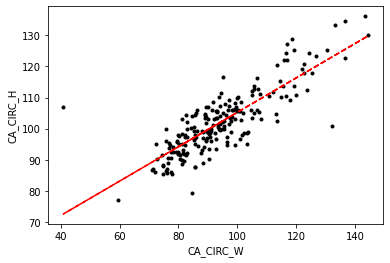

Scatter plot (Female)
Regression line: Y = 0.77 X + 34.54
R-Squared value: 0.69 


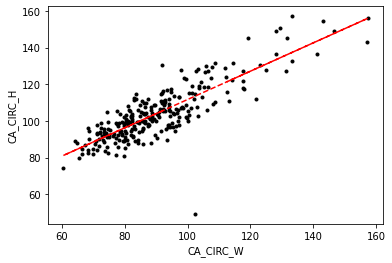

In [14]:
Scatt_plot(in_data,feat_list)